# Balanced and unbalanced gradient flows of a relative entropy

This notebook generates `fig:gradflow-wfr-unbalanced-flow`.  It compares the balanced Wasserstein gradient flow of the finite-measure relative entropy
$$
    F(\rho\,dx)=\operatorname{KL}(\rho\,dx\mid b\,dx)
    =\int \left(\rho\log(\rho/b)-\rho+b\right)\,dx
$$
with its Wasserstein--Fisher--Rao counterpart.  The balanced evolution is the conservative Fokker--Planck equation
$$
    \partial_t\rho=\partial_x^2\rho-\partial_x(\rho\,\partial_x\log b),
$$
whereas the unbalanced flow adds the local birth--death term
$$
    -\kappa^{-2}\rho\log(\rho/b).
$$
Both evolutions start from the same one-dimensional Gaussian mixture and are compared against the same target density $b$.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.resolve().parent
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import splu
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "gradflow-wfr-unbalanced-flow"
OUT = figure_dir(NAME)
THUMB = Path("thumbnails") / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)


## Densities and finite-volume operator

The Fokker--Planck part is discretized conservatively as a no-flux finite-volume operator, so the balanced run preserves total mass.  The unbalanced reaction is applied by an exact pointwise step, since for fixed target density `beta` the equation `d rho/dt = -gamma rho log(rho/beta)` has a closed-form update.


In [2]:
def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)


def normalize_density(rho, x):
    rho = np.maximum(np.asarray(rho, dtype=float), 1e-14)
    return rho / np.trapezoid(rho, x)


N = 560
x = np.linspace(-3.3, 3.3, N)
dx = x[1] - x[0]

rho0 = normalize_density(
    0.72 * gaussian(x, -1.70, 0.23)
    + 0.28 * gaussian(x, 0.20, 0.38),
    x,
)
beta = normalize_density(
    0.26 * gaussian(x, -0.55, 0.28)
    + 0.52 * gaussian(x, 1.05, 0.24)
    + 0.22 * gaussian(x, 1.90, 0.34),
    x,
)

score_beta = np.gradient(np.log(np.maximum(beta, 1e-14)), dx)
score_mid = 0.5 * (score_beta[:-1] + score_beta[1:])

# Conservative matrix for rho_t = Delta rho - div(rho grad log beta).
rows, cols, data = [], [], []
def add(i, j, value):
    rows.append(i)
    cols.append(j)
    data.append(value)

for edge, score in enumerate(score_mid):
    # Flux through edge i+1/2: J = -rho_x + rho * (log beta)_x.
    left_coeff = 1.0 / dx + 0.5 * score
    right_coeff = -1.0 / dx + 0.5 * score
    add(edge, edge, -left_coeff / dx)
    add(edge, edge + 1, -right_coeff / dx)
    add(edge + 1, edge, left_coeff / dx)
    add(edge + 1, edge + 1, right_coeff / dx)

L = sparse.csr_matrix((data, (rows, cols)), shape=(N, N))
assert np.abs(np.asarray(L.sum(axis=0)).ravel()).max() < 1e-9


## Balanced and WFR evolutions

The balanced flow uses only the conservative Fokker--Planck operator.  The WFR flow uses the same transport-diffusion operator and an additional reaction strength `gamma = kappa^{-2}`.


In [3]:
times = np.array([0.0, 0.12, 0.35, 0.90, 2.40])
T = float(times[-1])
dt = 0.004
steps = int(round(T / dt))
dt = T / steps
snap_steps = [int(round(t / dt)) for t in times]

implicit_solver = splu((sparse.eye(N, format="csc") - dt * L.tocsc()))


def reaction_step(rho, gamma):
    # Exact solution of d rho/dt = -gamma rho log(rho/beta) over one step.
    theta = np.exp(-gamma * dt)
    ratio = np.maximum(rho, 1e-14) / np.maximum(beta, 1e-14)
    return beta * ratio ** theta


def integrate(gamma=0.0):
    rho = rho0.copy()
    snapshots = []
    for k in range(steps + 1):
        if k in snap_steps:
            snapshots.append(rho.copy())
        if k == steps:
            break
        rho = implicit_solver.solve(rho)
        rho = np.maximum(rho, 1e-14)
        if gamma > 0:
            rho = reaction_step(rho, gamma)
        else:
            rho = normalize_density(rho, x)
    return np.stack(snapshots)


balanced = integrate(gamma=0.0)
kappa = 0.60
unbalanced = integrate(gamma=1.0 / kappa**2)

balanced_masses = np.array([np.trapezoid(rho, x) for rho in balanced])
unbalanced_masses = np.array([np.trapezoid(rho, x) for rho in unbalanced])
balanced_l1 = np.trapezoid(np.abs(balanced[-1] - beta), x)
unbalanced_l1 = np.trapezoid(np.abs(unbalanced[-1] - beta), x)

def kl_to_beta(rho):
    ratio = np.maximum(rho, 1e-14) / np.maximum(beta, 1e-14)
    return np.trapezoid(rho * np.log(ratio) - rho + beta, x)

balanced_kl = np.array([kl_to_beta(rho) for rho in balanced])
unbalanced_kl = np.array([kl_to_beta(rho) for rho in unbalanced])

assert np.allclose(balanced_masses, 1.0, atol=3e-6)
assert np.all(np.isfinite(unbalanced)) and np.all(unbalanced > 0)
assert balanced_kl[-1] < balanced_kl[0]
assert unbalanced_kl[-1] < unbalanced_kl[0]
assert unbalanced_l1 < 0.02
assert unbalanced_l1 < 0.55 * balanced_l1


## Exported panels

The PDFs contain no title.  The light gray curve in each stack is the target density `beta`, repeated as a reference; the colored density evolves from red to blue.


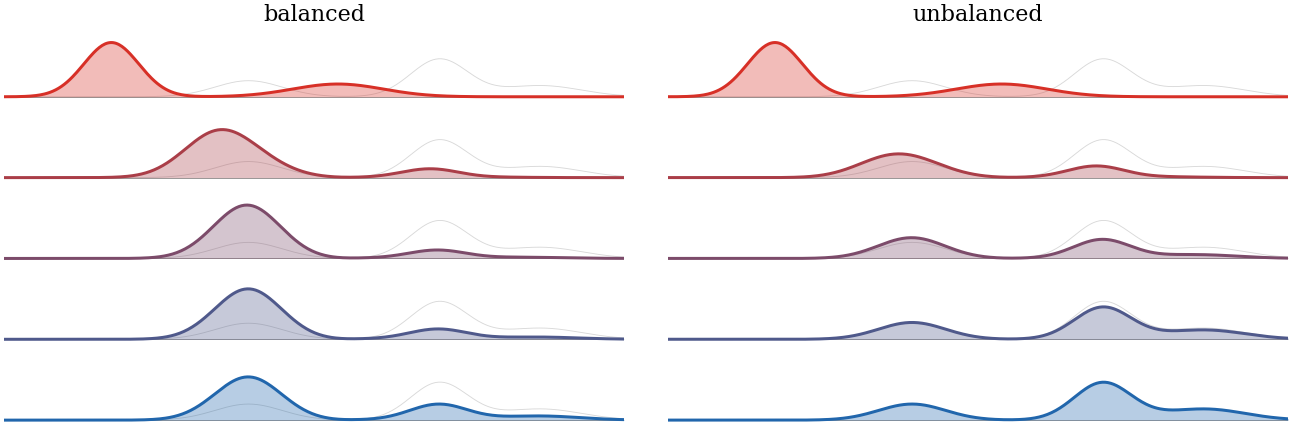

In [4]:
ROWS = len(times)
BASE = (ROWS - 1 - np.arange(ROWS)) * 0.82
SCALE = 0.55 / max(balanced.max(), unbalanced.max(), beta.max())
PANEL_XLIM = (-2.60, 2.60)


def draw_stack(ax, curves):
    for k, rho in enumerate(curves):
        y0 = BASE[k]
        color = interp_color(k / (ROWS - 1), RED, BLUE)
        ax.plot(x, y0 + SCALE * beta, color="#2a2a2a", lw=0.32, alpha=0.18, zorder=1)
        ax.fill_between(x, y0, y0 + SCALE * rho, color=color, alpha=0.32, linewidth=0, zorder=2)
        ax.plot(x, y0 + SCALE * rho, color=color, lw=1.08, solid_capstyle="round", zorder=3)
        ax.axhline(y0, color="#222222", lw=0.32, alpha=0.50, zorder=0)
    ax.set_xlim(*PANEL_XLIM)
    ax.set_ylim(-0.10, BASE[0] + 0.72)
    remove_axes(ax)


def save_panel(curves, filename):
    fig, ax = plt.subplots(figsize=(3.18, 2.12))
    draw_stack(ax, curves)
    fig.subplots_adjust(0, 0, 1, 1)
    save_pdf(fig, OUT / filename, pad_inches=0.015)
    plt.close(fig)


save_panel(balanced, "balanced.pdf")
save_panel(unbalanced, "unbalanced.pdf")

fig, axes = plt.subplots(1, 2, figsize=(6.55, 2.35))
for ax, curves, title in zip(axes, [balanced, unbalanced], ["balanced", "unbalanced"]):
    draw_stack(ax, curves)
    ax.set_title(title, fontsize=8, pad=1)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.88, wspace=0.07)
fig.savefig(THUMB, dpi=200, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)
display(Image(filename=str(THUMB)))


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


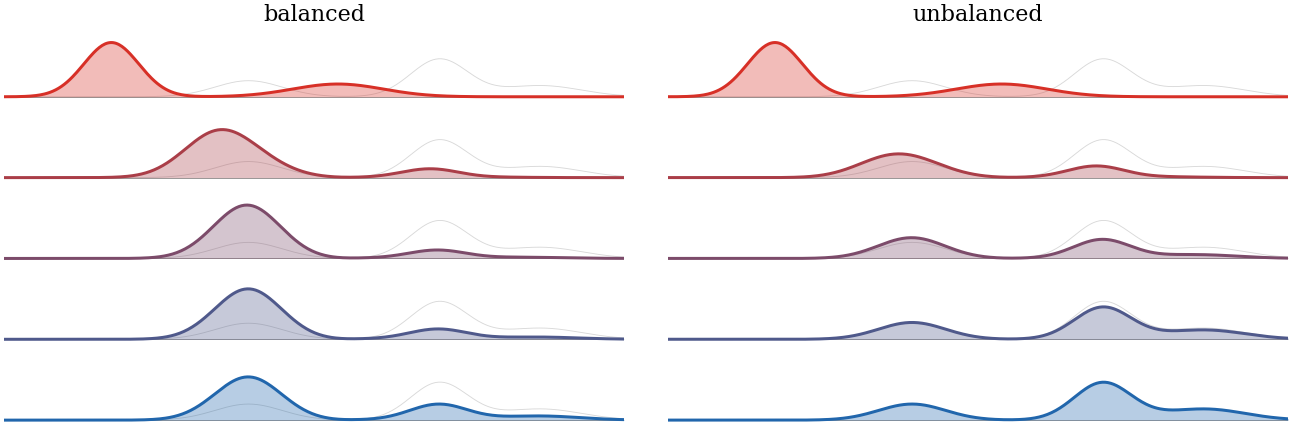

In [5]:
_thumb = Path("thumbnails/gradflow-wfr-unbalanced-flow.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gradflow-wfr-unbalanced-flow.png")
display(Image(filename=str(_thumb)))
